#### Cohort Analysis
##### Date: 2025-12-29

**Topics:**
> 1. Cohort Analysis 
> 2. Pivot table 
> 3. Metrics 
> 4. Heatmap 

**Materials:**
> 1. [Step by step](https://www.adasight.com/blog/cohort-analysis-definition-key-steps-examples)
> 2. [Cohort Analysis example](https://hex.tech/templates/reporting/cohort-analysis/)

#### Когорта 
Це група користувачів, об’єднаних спільною подією у певний період часу

**Когорта** — це множина користувачів, які:
> мали однакову стартову подію \
> у чітко визначений період часу


**Приклади когорт:**
> користувачі, які зареєструвались у <month> \
> користувачі, які зробили першу покупку \
> користувачі, які пройшли онбординг \
> користувачі, які прийшли з Facebook

Основна проблема метрик, не зрозуміло в порівнянням з цим стало краще/гірше. 

**Що дає когортний аналіз:**
> де саме користувачі йдуть \
> у яких когортах стало краще \
> як змінюється поведінка з часом


**Типові випадки використання:**
> чи покращується продукт з часом? \
> які користувачі продовжують користуватись? \
> чи спрацювали зміни в продукті? \
> де основний відтік? \
> чи є проблеми з онбордингом?

| Cohort  | М0   | М1  | М2  | М3  |
| ------- | ---- | --- | --- | --- |
| 2024-01 | 100% | 32% | 21% | 15% |
| 2024-02 | 100% | 40% | 29% | 22% |
| 2024-03 | 100% | 48% | —   | —   |


#### Часові когорти (Time-based cohorts)
Користувачі групуються за моментом стартової події:
> реєстрація \
> перша покупка \
> перша активність

Когорта = місяць реєстрації
| Cohort  | M0   | M1  | M2  |
| ------- | ---- | --- | --- |
| 2024-01 | 100% | 30% | 18% |
| 2024-02 | 100% | 38% | 25% |
---
#### Поведінкові когорти (Behavioral cohorts)
Когорта формується за дією або набором дій, які зробив користувач.

**Приклади:**
> подивився ≥3 товарів \
> зробив покупку \
> завершив онбординг \
> додав карту
---
#### Когорти за джерелом (Acquisition cohorts)
Користувачі групуються за каналом залучення.

| Channel  | M1 retention |
| -------- | ------------ |
| Facebook | 22%          |
| Google   | 35%          |
| Referral | 58%          |
---
#### Когорти за продуктом / тарифом

**Групування за:**
> тарифом \
> планом \
> типом продукту

| Plan    | M3 retention |
| ------- | ------------ |
| Free    | 12%          |
| Premium | 48%          |

---
#### Географічні когорти

**Користувачі групуються за:**
> країною \
> регіоном \
> містом

| Country | M1 retention |
| ------- | ------------ |
| UA      | 40%          |
| KZ      | 28%          |
| PL      | 18%          |

---
#### Когорти за пристроєм / платформою

**Групування за:**
> iOS / Android / Web \
> Smart TV \
> Console

| Platform | M1 retention |
| -------- | ------------ |
| iOS      | 45%          |
| Android  | 38%          |
| Smart TV | 62%          |

---
#### Комбіновані (multi-dimensional) когорти

Когорта = (місяць реєстрації + канал + тариф)


Когортний аналіз завжди закінчується таблицею виду:
> рядки -> когорти \
> колонки -> час з моменту старту (offset) \
> значення -> метрика (users, retention, revenue)

pivot_table - зведена таблиця
```python
pd.pivot_table(
    data,
    index=...,
    columns=...,
    values=...,
    aggfunc=...
)
```
| Елемент   | У когортному аналізі          |
| --------- | ----------------------------- |
| `index`   | cohort (місяць реєстрації)    |
| `columns` | offset (місяць/тиждень життя) |
| `values`  | user_id / revenue             |
| `aggfunc` | nunique / sum                 |



In [29]:
import pandas as pd

df = pd.DataFrame({
    "user_id": [1,1,2,3,3,4],
    "signup_month": ["2024-01","2024-01","2024-01","2024-02","2024-02","2024-02"],
    "active_month": ["2024-01","2024-02","2024-01","2024-02","2024-03","2024-02"]
})

df


,user_id,signup_month,active_month
0,1,2024-01,2024-01
1,1,2024-01,2024-02
2,2,2024-01,2024-01
3,3,2024-02,2024-02
4,3,2024-02,2024-03
5,4,2024-02,2024-02


In [ ]:
# Step 1. Підготувати данні 
df["signup_month"] = pd.to_datetime(df["signup_month"])
df["active_month"] = pd.to_datetime(df["active_month"])


In [4]:
# Step 2. Порахувати offset 
df["cohort_index"] = (
    (df["active_month"].dt.year - df["signup_month"].dt.year) * 12 +
    (df["active_month"].dt.month - df["signup_month"].dt.month)
)

df

,user_id,signup_month,active_month,cohort_index
0,1,2024-01-01,2024-01-01,0
1,1,2024-01-01,2024-02-01,1
2,2,2024-01-01,2024-01-01,0
3,3,2024-02-01,2024-02-01,0
4,3,2024-02-01,2024-03-01,1
5,4,2024-02-01,2024-02-01,0


In [ ]:
# Step 3. Будуємо Pivot_table 
cohort_counts = pd.pivot_table(
    df,
    index="signup_month",
    columns="cohort_index",
    values="user_id",
    aggfunc="nunique"
)
cohort_counts

cohort_index,0,1
signup_month,,
2024-01-01,2,1
2024-02-01,2,1


In [8]:
# Step 4. Retention або інша метрика
cohort_sizes = cohort_counts.iloc[:, 0]

retention = cohort_counts.divide(cohort_sizes, axis=0)

retention = retention.round(3) * 100
retention


cohort_index,0,1
signup_month,,
2024-01-01,100.0,50.0
2024-02-01,100.0,50.0


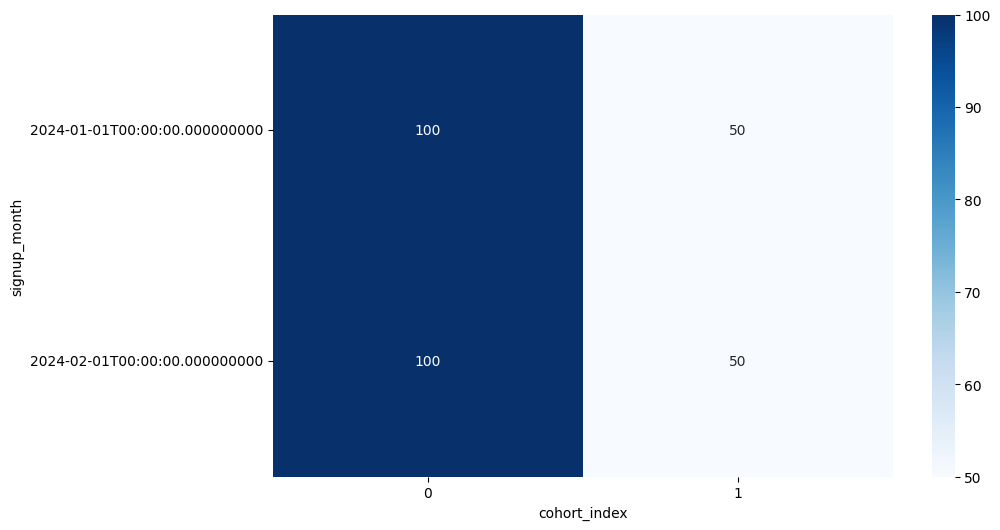

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)
plt.show()


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns

In [38]:
# Приклад
df = pd.read_excel('Online Retail.xlsx') # !! треба змінити на свій шлях !!

In [43]:
df.shape

(541909, 8)

In [46]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [49]:
df['CustomerID'].unique()

array([17850., 13047., 12583., ..., 13298., 14569., 12713.], shape=(4373,))

In [48]:
df[df['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [35]:
# EDA
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,OrderMonth,CohortMonth,CohortIndex,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12,2010-12,1,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,2010-12,1,20.34


In [51]:
df.shape

(541909, 8)

In [52]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [54]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [ ]:
# yyyy-mm-dd hh:mm:ss.ms 
# 9999-13-32 25:61:61

In [53]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [57]:
df['Quantity'].max(), df['Quantity'].min()

(np.int64(80995), np.int64(-80995))

In [60]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [58]:
df[df['Quantity'] < 0].shape

(10624, 8)

In [55]:
df['UnitPrice'].max(), df['UnitPrice'].min()

(np.float64(38970.0), np.float64(-11062.06))

In [39]:
df['Quantity'].unique()

array([     6,      8,      2,     32,      3,      4,     24,     12,
           48,     18,     20,     36,     80,     64,     10,    120,
           96,     23,      5,      1,     -1,     50,     40,    100,
          192,    432,    144,    288,    -12,    -24,     16,      9,
          128,     25,     30,     28,      7,     56,     72,    200,
          600,    480,     -6,     14,     -2,     11,     33,     13,
           -4,     -5,     -7,     -3,     70,    252,     60,    216,
          384,    -10,     27,     15,     22,     19,     17,     21,
           34,     47,    108,     52,  -9360,    -38,     75,    270,
           42,    240,     90,    320,   1824,    204,     69,    -36,
         -192,   -144,    160,   2880,   1400,     39,    -48,    -50,
           26,   1440,     31,     82,     78,     97,     98,     35,
           57,    -20,    110,    -22,    -30,    -70,   -130,    -80,
         -120,    -40,    -25,    -14,    -15,    -69,   -140,   -320,
      

In [36]:
df['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Saudi Arabia', 'Czech Republic', 'Canada',
       'Unspecified', 'Brazil', 'USA', 'European Community', 'Bahrain',
       'Malta', 'RSA'], dtype=object)

In [ ]:
# 8 колонок, 2 двух колонках є пропуски: ..., ..., у % пропуски займають: ..., .... наявні/дублікати. В двух колонках в нас uncorrect data.
# data cleaning: drop duplicates,  dropna/filter NaN Customed_id. 
# Filter: UnitPrice > 0 and not NaN, Q > 0 and not NaN
# Before data cleaning: ... after: ...;


In [61]:
# Data cleaning
df.drop_duplicates(inplace=True)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0) & (df['CustomerID'].notnull())]

In [65]:
df['UnitPrice'].min(), df['UnitPrice'].max()

(np.float64(0.001), np.float64(8142.75))

In [64]:
df['Quantity'].min(), df['Quantity'].max()

(np.int64(1), np.int64(80995))

In [63]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [62]:
df.shape

(392692, 8)

In [ ]:
# Cohort Analysis
# Month prepare
def get_month(x): return dt.datetime(x.year, x.month, 1)
df['InvoiceMonth'] = df['InvoiceDate'].apply(get_month)

# Start position 
grouping = df.groupby('CustomerID')['InvoiceMonth']
df['CohortMonth'] = grouping.transform('min') # agg (1 value) -> 17 rows - agg 1 value

In [67]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,2010-12-01


In [41]:
df[df['CustomerID'] == 17850.0]['InvoiceDate'].unique()

<DatetimeArray>
['2010-12-01 08:26:00', '2010-12-01 08:28:00', '2010-12-01 09:01:00',
 '2010-12-01 09:02:00', '2010-12-01 09:32:00', '2010-12-01 09:34:00',
 '2010-12-01 10:51:00', '2010-12-01 10:52:00', '2010-12-01 11:33:00',
 '2010-12-01 11:34:00', '2010-12-02 08:32:00', '2010-12-02 08:33:00',
 '2010-12-02 08:34:00', '2010-12-02 08:40:00', '2010-12-02 09:41:00',
 '2010-12-02 09:42:00', '2010-12-02 09:44:00', '2010-12-02 10:54:00',
 '2010-12-02 10:55:00', '2010-12-02 10:56:00', '2010-12-02 10:58:00',
 '2010-12-02 12:23:00', '2010-12-02 12:24:00', '2010-12-02 12:25:00',
 '2010-12-02 12:26:00', '2010-12-02 14:04:00', '2010-12-02 14:05:00',
 '2010-12-02 14:06:00', '2010-12-02 14:07:00', '2010-12-02 15:24:00',
 '2010-12-02 15:25:00', '2010-12-02 15:26:00', '2010-12-02 15:27:00',
 '2011-02-10 14:38:00']
Length: 34, dtype: datetime64[ns]

In [ ]:
# dd-mm-yyyy -> unique date

In [68]:
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    day = df[column].dt.day
    return year, month, day

In [ ]:
invoice_year, invoice_month, invoice_day = get_date_int(df, 'InvoiceMonth')
cohort_year, cohort_month, cohort_day = get_date_int(df, 'CohortMonth')

years_diff = invoice_year - cohort_year
months_diff = invoice_month - cohort_month

N:int = 12 # період аналізу
df['CohortIndex'] = years_diff * N + months_diff + 1

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth,CohortIndex
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01,2010-12-01,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,2010-12-01,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01,2010-12-01,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,2010-12-01,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,2010-12-01,1


In [71]:
df['CohortIndex'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13], dtype=int32)

In [70]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'InvoiceMonth', 'CohortMonth',
       'CohortIndex'],
      dtype='object')

In [74]:
grouping = df.groupby(['CohortMonth', 'CohortIndex'])

cohort_data = grouping['CustomerID'].apply(pd.Series.nunique)

cohort_data = cohort_data.reset_index()

cohort_counts = cohort_data.pivot(index='CohortMonth',
                                 columns='CohortIndex',
                                 values='CustomerID')

In [75]:
cohort_counts

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02-01,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03-01,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04-01,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05-01,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06-01,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
cohort_sizes

CohortMonth
2010-12-01    885.0
2011-01-01    417.0
2011-02-01    380.0
2011-03-01    452.0
2011-04-01    300.0
2011-05-01    284.0
2011-06-01    242.0
2011-07-01    188.0
2011-08-01    169.0
2011-09-01    299.0
2011-10-01    358.0
2011-11-01    323.0
2011-12-01     41.0
Name: 1, dtype: float64

In [ ]:
# Retention  d
cohort_sizes = cohort_counts.iloc[:,0] # обрати саму когорту

retention = cohort_counts.divide(cohort_sizes, axis=0) # сам retention
retention.index = retention.index.date

In [80]:
retention

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
2010-12-01,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02-01,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03-01,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04-01,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN
2011-05-01,1.0,0.190141,0.172535,0.172535,0.207746,0.232394,0.264085,0.095070,NaN,NaN,NaN,NaN,NaN
2011-06-01,1.0,0.173554,0.157025,0.264463,0.231405,0.334711,0.095041,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,1.0,0.180851,0.207447,0.223404,0.271277,0.111702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,1.0,0.207101,0.248521,0.242604,0.124260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-09-01,1.0,0.234114,0.301003,0.113712,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [81]:
retention.round(2) * 100

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
2010-12-01,100.0,37.0,32.0,38.0,36.0,40.0,36.0,35.0,35.0,40.0,37.0,50.0,27.0
2011-01-01,100.0,22.0,27.0,23.0,32.0,29.0,25.0,24.0,30.0,33.0,36.0,12.0,NaN
2011-02-01,100.0,19.0,19.0,28.0,27.0,25.0,25.0,28.0,25.0,31.0,7.0,NaN,NaN
2011-03-01,100.0,15.0,25.0,20.0,22.0,17.0,27.0,23.0,28.0,9.0,NaN,NaN,NaN
2011-04-01,100.0,21.0,20.0,21.0,20.0,23.0,22.0,26.0,7.0,NaN,NaN,NaN,NaN
2011-05-01,100.0,19.0,17.0,17.0,21.0,23.0,26.0,10.0,NaN,NaN,NaN,NaN,NaN
2011-06-01,100.0,17.0,16.0,26.0,23.0,33.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,100.0,18.0,21.0,22.0,27.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,100.0,21.0,25.0,24.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-09-01,100.0,23.0,30.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


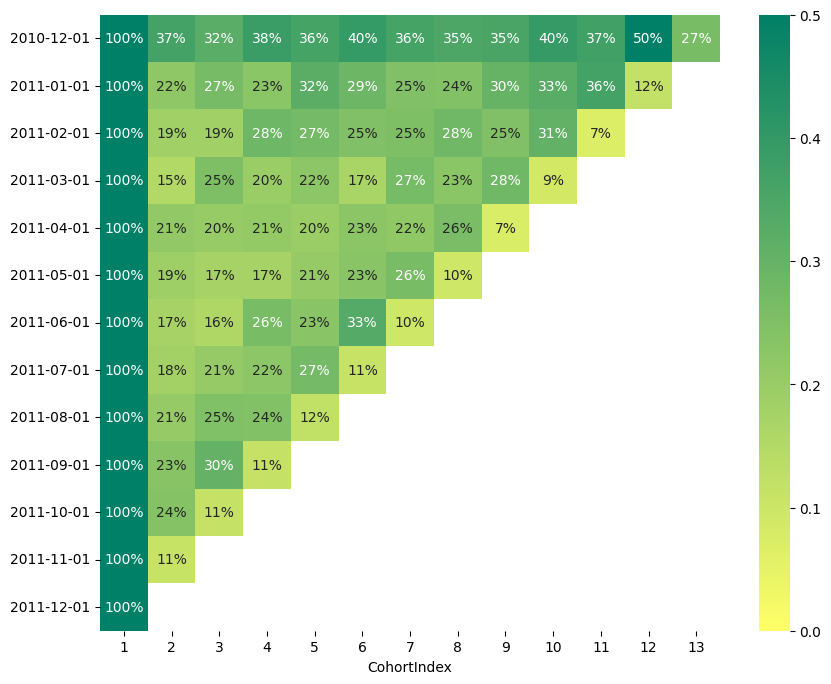

In [82]:
plt.figure(figsize=(10,8))
sns.heatmap(data = retention,
           annot = True,
           fmt = '.0%',
           vmin= 0.0,
           vmax=0.5,
           cmap='summer_r');

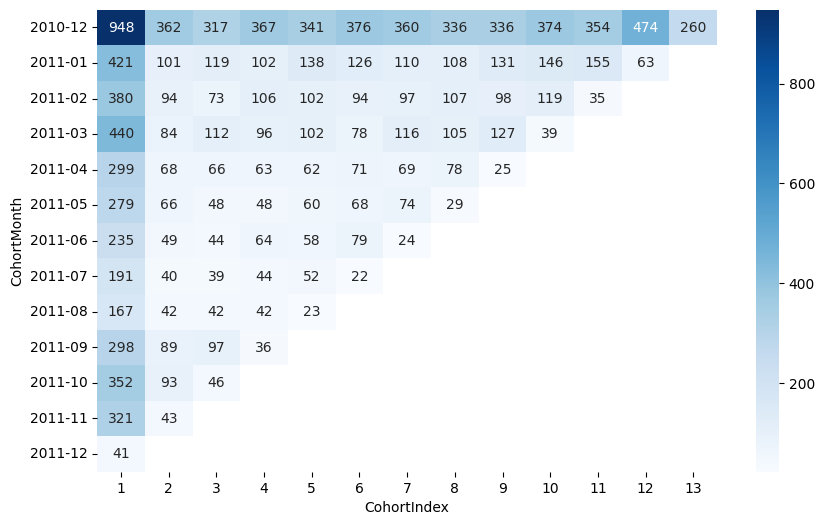

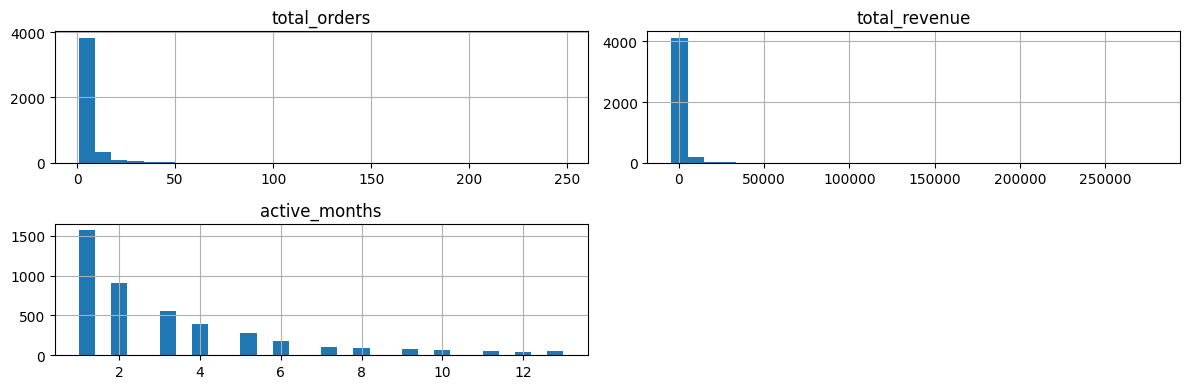

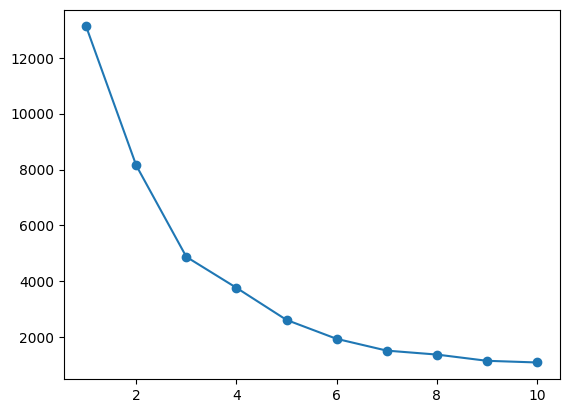

2 0.7382955492897607
3 0.6977283517986297
4 0.6321358113411091
5 0.5971929742972795
6 0.5992256140699266


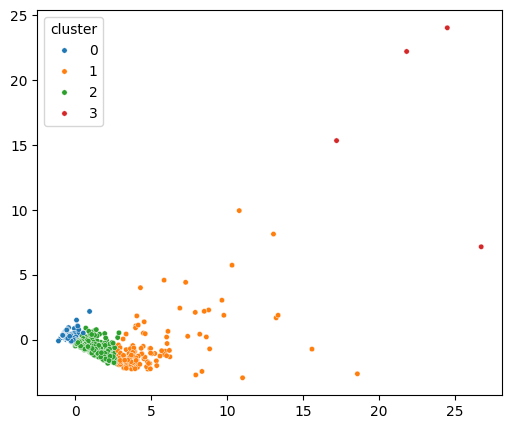

In [ ]:
import pandas as pd

df = df.dropna(subset=["CustomerID"])

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["OrderMonth"] = df["InvoiceDate"].dt.to_period("M")

# Cohort -> first buy
df["CohortMonth"] = df.groupby("CustomerID")["OrderMonth"].transform("min")


# Index month

df["CohortIndex"] = (
    (df["OrderMonth"].dt.year - df["CohortMonth"].dt.year) * 12 +
    (df["OrderMonth"].dt.month - df["CohortMonth"].dt.month) + 1
)

# Cohort table
cohort_counts = (
    df.groupby(["CohortMonth", "CohortIndex"])["CustomerID"]
    .nunique()
    .reset_index()
)

cohort_pivot = cohort_counts.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="CustomerID"
)

# Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(cohort_pivot, annot=True, fmt=".0f", cmap="Blues")

plt.show()

df["Revenue"] = df["Quantity"] * df["UnitPrice"]

customer_features = df.groupby("CustomerID").agg(
    total_orders=("InvoiceNo", "nunique"),
    total_revenue=("Revenue", "sum"),
    active_months=("OrderMonth", "nunique")
)


customer_features.hist(bins=30, figsize=(12,4))
plt.tight_layout()
plt.show()


#
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_features)



# Вибір  
from sklearn.cluster import KMeans

inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,11), inertia, marker="o")
plt.show()




from sklearn.metrics import silhouette_score

for k in range(2,7):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    print(k, silhouette_score(X_scaled, labels))



kmeans = KMeans(n_clusters=4, random_state=42)
customer_features["cluster"] = kmeans.fit_predict(X_scaled)




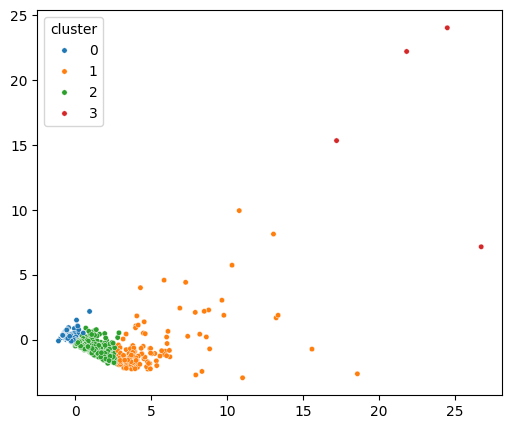

In [83]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=customer_features["cluster"],
    palette="tab10",
    s=15
)
plt.show()

In [85]:
df = df.merge(
    customer_features["cluster"],
    on="CustomerID"
)
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth,CohortIndex,cluster_x,cluster_y
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01,2010-12-01,1,2,2
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,2010-12-01,1,2,2
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01,2010-12-01,1,2,2
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,2010-12-01,1,2,2
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,2010-12-01,1,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
392687,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,2011-12-01,2011-08-01,5,0,0
392688,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,2011-12-01,2011-08-01,5,0,0
392689,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,2011-12-01,2011-08-01,5,0,0
392690,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,2011-12-01,2011-08-01,5,0,0


In [86]:
pd.crosstab(
    df["CohortMonth"],
    df["cluster"],
    normalize="index"
)


KeyError: 'cluster'